In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

In [2]:
#load data
data_path = Path("../data/raw/S1_A1_E1.mat")

data = loadmat(data_path)

In [3]:
data.keys()

dict_keys(['__header__', '__version__', '__globals__', 'emg', 'stimulus', 'glove', 'subject', 'exercise', 'repetition', 'restimulus', 'rerepetition'])

In [4]:
emg = data["emg"]
labels = data["restimulus"].flatten()
repetitions = data["rerepetition"].flatten()

print("EMG shape:", emg.shape)
print("Labels shape:", labels.shape)
print("Repetitions shape:", repetitions.shape)

EMG shape: (101014, 10)
Labels shape: (101014,)
Repetitions shape: (101014,)


In [5]:
print("Unique movement labels:", np.unique(labels))
print("Unique repetitions:", np.unique(repetitions))

Unique movement labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12]
Unique repetitions: [ 0  1  2  3  4  5  6  7  8  9 10]


In [39]:
#plot channel 1

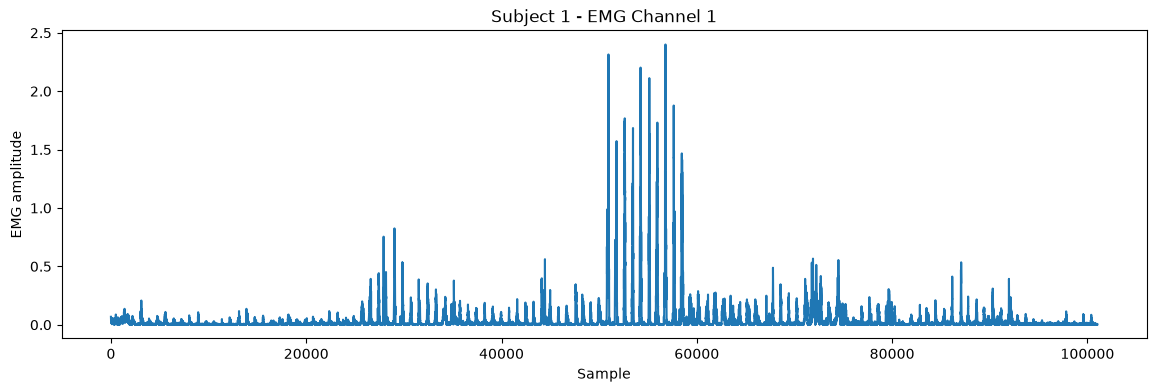

In [6]:
plt.figure(figsize=(14, 4))

plt.plot(emg[:, 0])

plt.xlabel("Sample")
plt.ylabel("EMG amplitude")
plt.title("Subject 1 - EMG Channel 1")

plt.show()

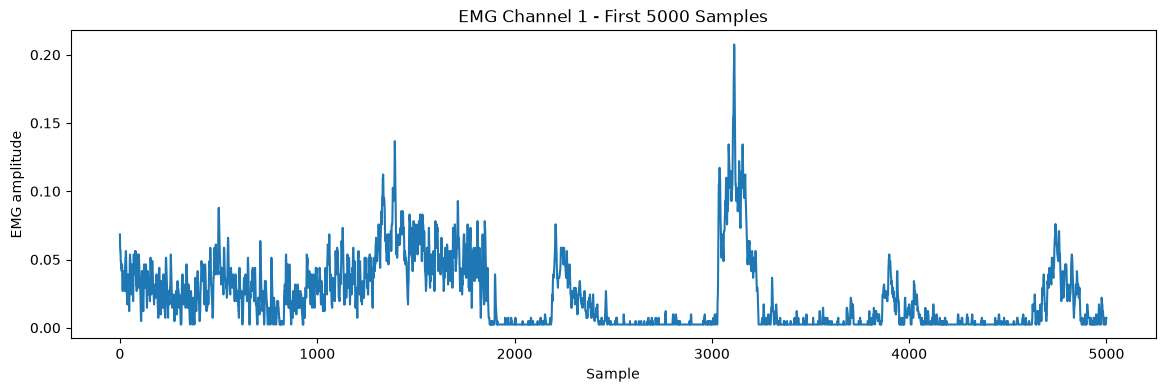

In [7]:
start = 0
end = 5000

plt.figure(figsize=(14, 4))

plt.plot(emg[start:end, 0])

plt.xlabel("Sample")
plt.ylabel("EMG amplitude")
plt.title("EMG Channel 1 - First 5000 Samples")

plt.show()

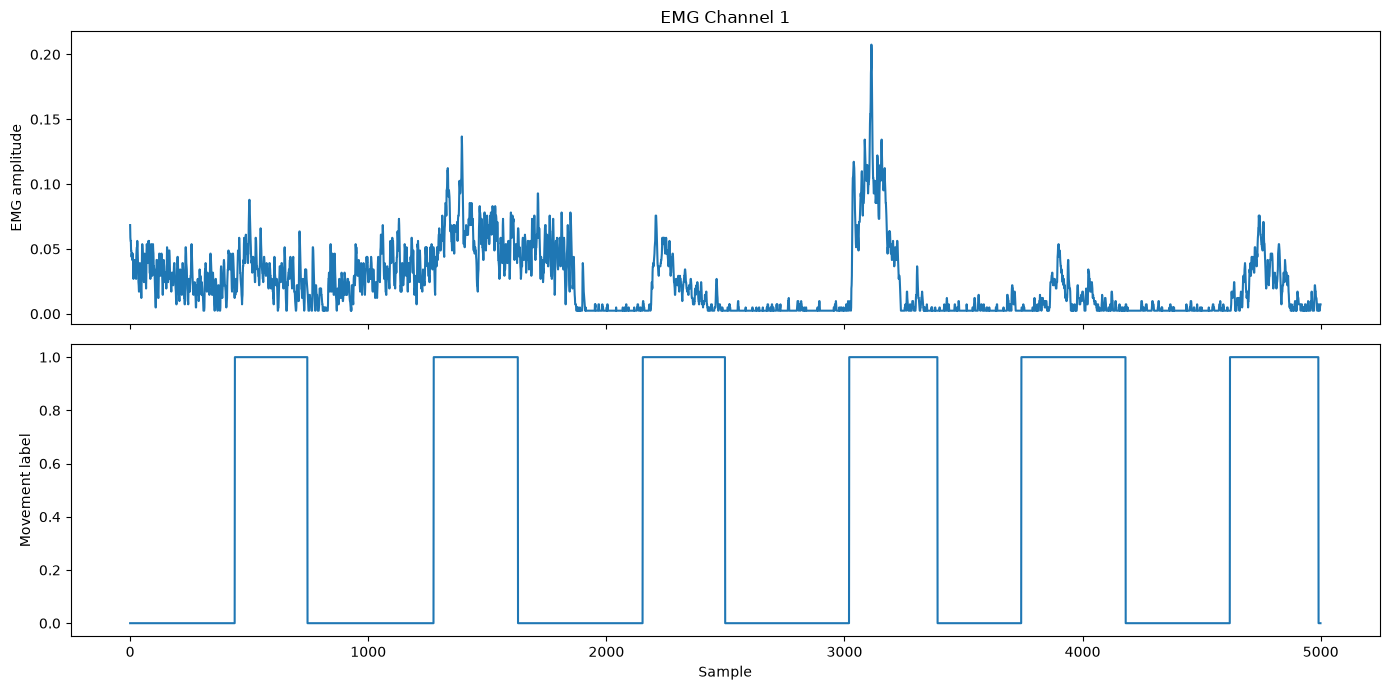

In [8]:
#bursts in the EMG roughly line up with periods where the movement label changes
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(emg[start:end, 0])
axes[0].set_ylabel("EMG amplitude")
axes[0].set_title("EMG Channel 1")

axes[1].plot(labels[start:end])
axes[1].set_ylabel("Movement label")
axes[1].set_xlabel("Sample")

plt.tight_layout()
plt.show()

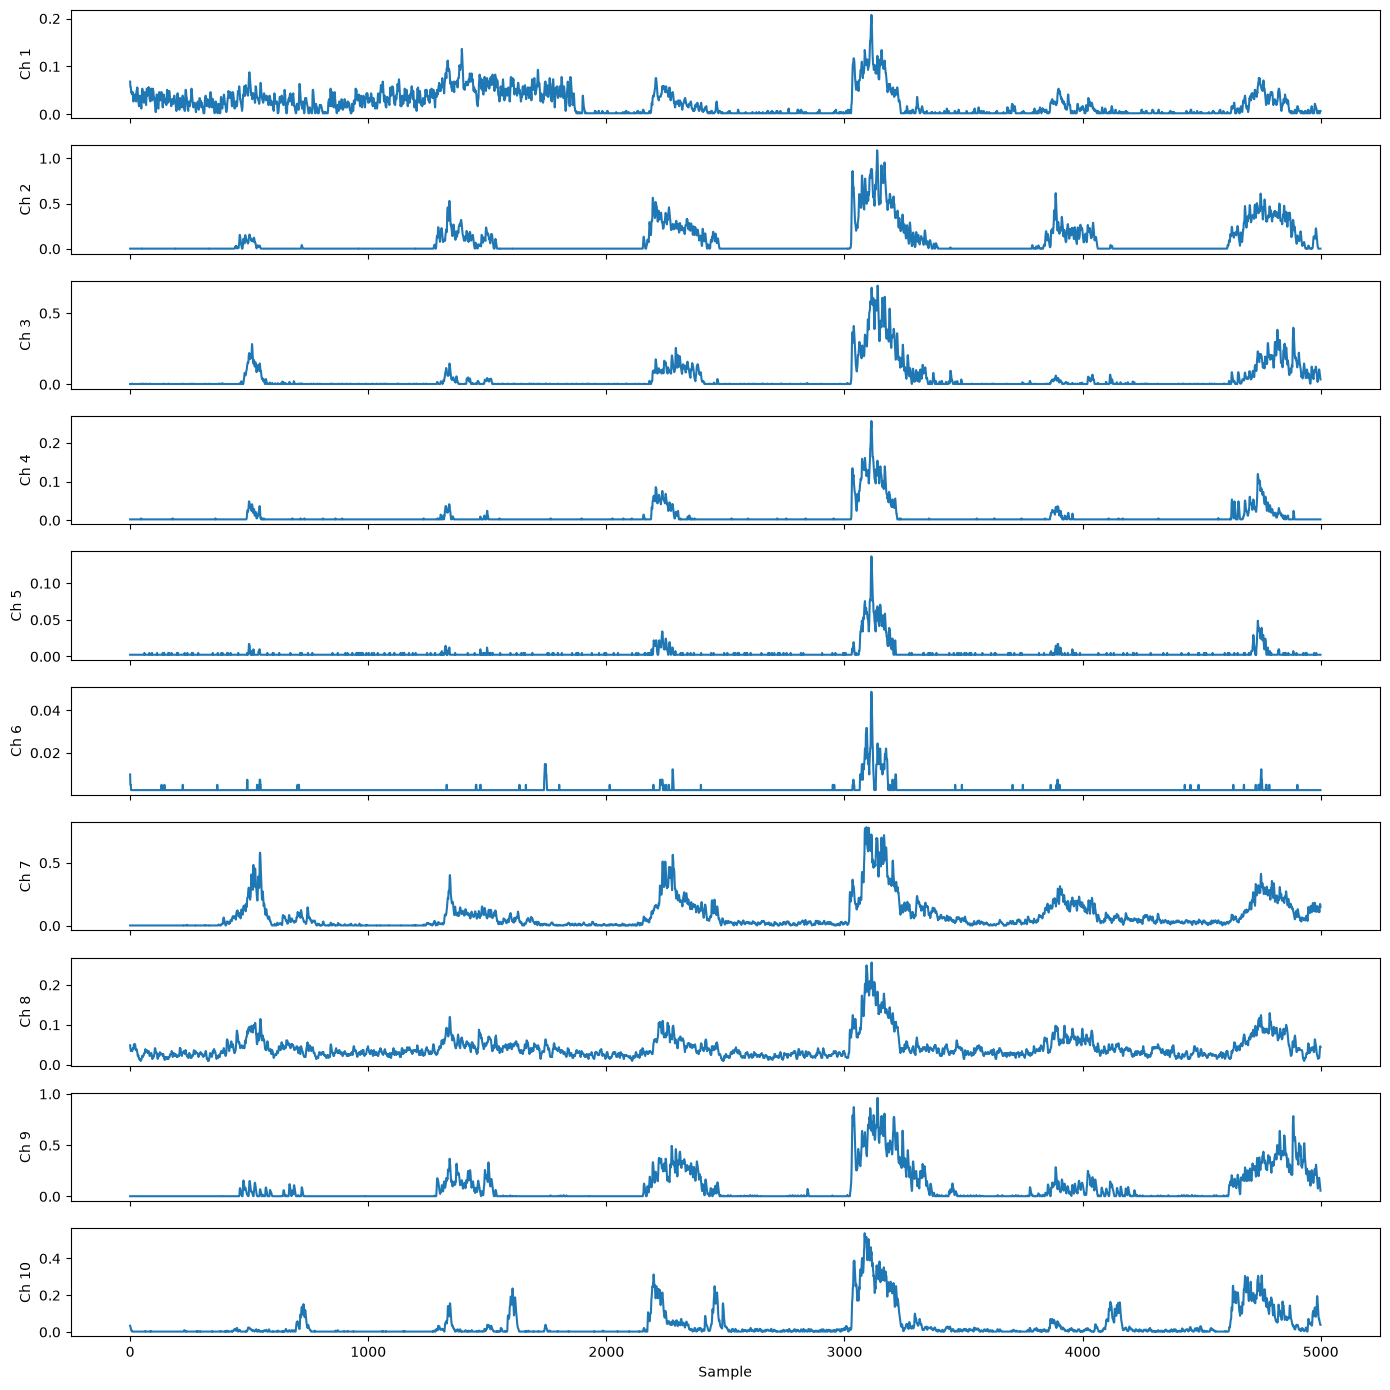

In [9]:
start = 0
end = 5000

fig, axes = plt.subplots(10, 1, figsize=(14, 14), sharex=True)

for ch in range(10):
    axes[ch].plot(emg[start:end, ch])
    axes[ch].set_ylabel(f"Ch {ch+1}")

axes[-1].set_xlabel("Sample")

plt.tight_layout()
plt.show()

In [10]:
movement = 1

mask = labels == movement

movement_emg = emg[mask]

print("Shape:", movement_emg.shape)

Shape: (3815, 10)


In [11]:
emg[mask]

array([[0.0171, 0.0073, 0.0024, ..., 0.0317, 0.0024, 0.0146],
       [0.0171, 0.0244, 0.0024, ..., 0.0342, 0.0024, 0.0146],
       [0.0146, 0.0269, 0.0024, ..., 0.0342, 0.0024, 0.0146],
       ...,
       [0.0024, 0.0024, 0.0415, ..., 0.0269, 0.0513, 0.0488],
       [0.0024, 0.0024, 0.0464, ..., 0.022 , 0.0684, 0.0488],
       [0.0024, 0.0024, 0.0366, ..., 0.0171, 0.0659, 0.0415]],
      shape=(3815, 10))

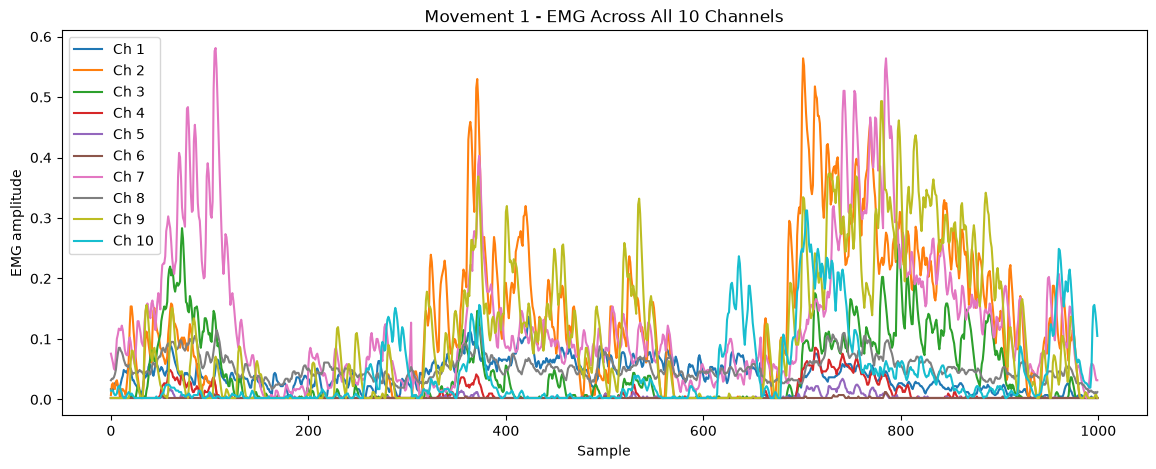

In [12]:
plt.figure(figsize=(14, 5))

for ch in range(10):
    plt.plot(movement_emg[:1000, ch], label=f"Ch {ch+1}")

plt.xlabel("Sample")
plt.ylabel("EMG amplitude")
plt.title("Movement 1 - EMG Across All 10 Channels")

plt.legend()
plt.show()

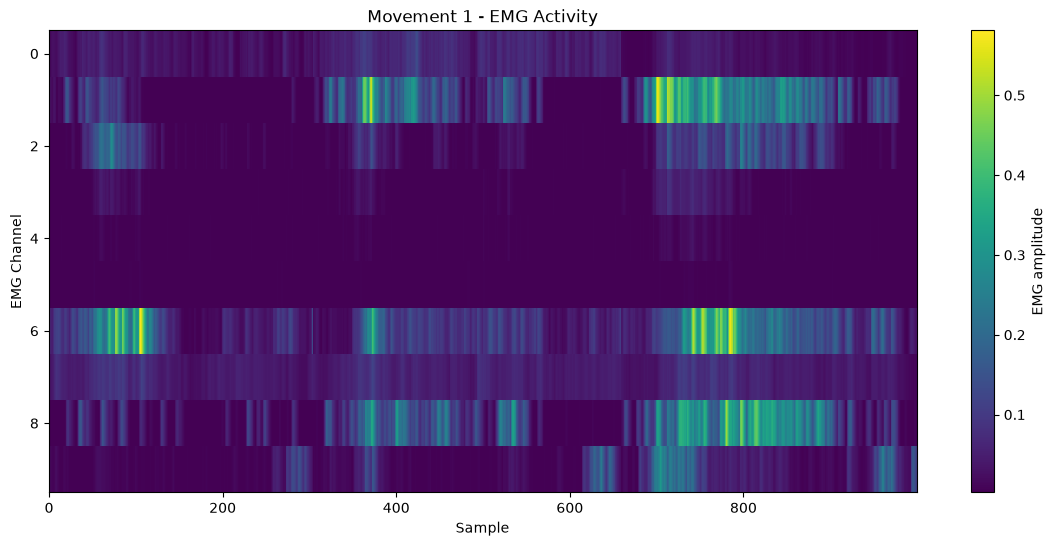

In [13]:
plt.figure(figsize=(14, 6))

plt.imshow(
    movement_emg[:1000].T,
    aspect="auto",
    interpolation="nearest"
)

plt.xlabel("Sample")
plt.ylabel("EMG Channel")
plt.title("Movement 1 - EMG Activity")

plt.colorbar(label="EMG amplitude")
plt.show()

In [14]:
movement = 1
rep = 1

mask = (labels == movement) & (repetitions == rep)

movement_rep_emg = emg[mask]

print("Shape:", movement_rep_emg.shape)

Shape: (305, 10)


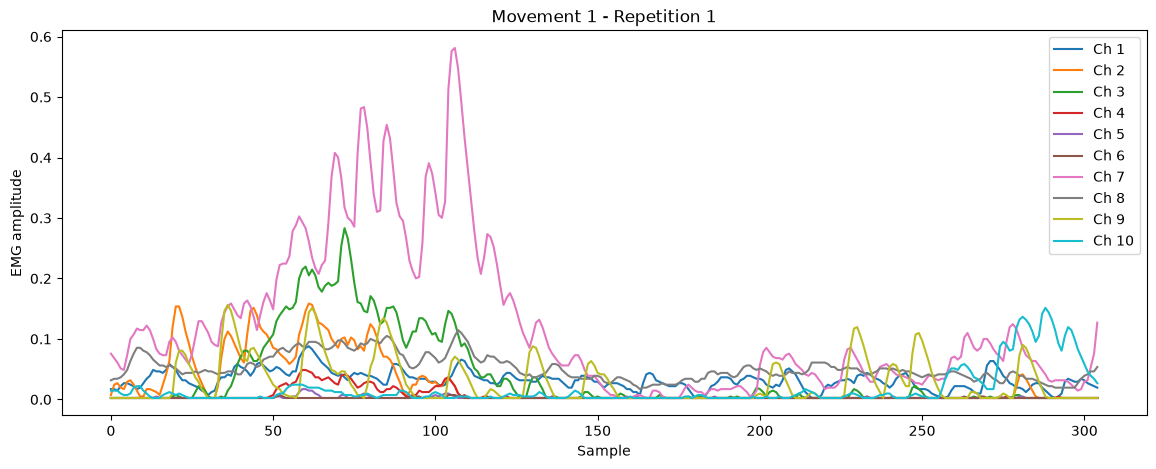

In [15]:
plt.figure(figsize=(14, 5))

for ch in range(10):
    plt.plot(movement_rep_emg[:, ch], label=f"Ch {ch+1}")

plt.xlabel("Sample")
plt.ylabel("EMG amplitude")
plt.title("Movement 1 - Repetition 1")

plt.legend()
plt.show()

In [16]:
rep1 = emg[(labels == 1) & (repetitions == 1)]
rep2 = emg[(labels == 1) & (repetitions == 2)]

print("Rep 1:", rep1.shape)
print("Rep 2:", rep2.shape)

Rep 1: (305, 10)
Rep 2: (354, 10)


In [18]:
print(rep1.shape)

(305, 10)


In [38]:
#create windows

In [19]:
window_size = 20

In [20]:
windows = []

for start in range(0, len(rep1) - window_size + 1, window_size):
    end = start + window_size
    window = rep1[start:end]
    windows.append(window)

windows = np.array(windows)

print(windows.shape)

(15, 20, 10)


In [21]:
print(windows[0].shape)

(20, 10)


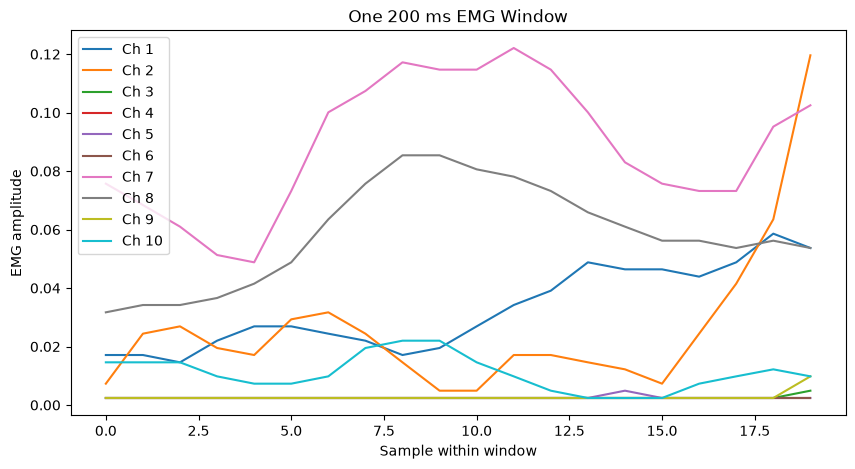

In [22]:
plt.figure(figsize=(10, 5))

for ch in range(10):
    plt.plot(windows[0][:, ch], label=f"Ch {ch+1}")

plt.xlabel("Sample within window")
plt.ylabel("EMG amplitude")
plt.title("One 200 ms EMG Window")

plt.legend()
plt.show()

In [23]:
windows.shape

(15, 20, 10)

In [24]:
#overlapping windows
window_size = 20
step_size = 10

windows = []

for start in range(0, len(rep1) - window_size + 1, step_size):
    end = start + window_size
    window = rep1[start:end]
    windows.append(window)

windows = np.array(windows)

print(windows.shape)

(29, 20, 10)


In [25]:
#function to create windows
def create_windows(signal, window_size=20, step_size=10):
    windows = []

    for start in range(0, len(signal) - window_size + 1, step_size):
        end = start + window_size
        window = signal[start:end]
        windows.append(window)

    return np.array(windows)

In [40]:
test_windows = create_windows(rep1)

print(test_windows.shape)

(29, 20, 10)


In [27]:
#dataset across 10 reps
X = []
y = []
rep_ids = []

movement = 1

for rep in range(1, 11):
    mask = (labels == movement) & (repetitions == rep)
    signal = emg[mask]

    rep_windows = create_windows(signal)

    for window in rep_windows:
        X.append(window)
        y.append(movement)
        rep_ids.append(rep)

X = np.array(X)
y = np.array(y)
rep_ids = np.array(rep_ids)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("rep_ids shape:", rep_ids.shape)

X shape: (368, 20, 10)
y shape: (368,)
rep_ids shape: (368,)


In [28]:
print("Unique labels:", np.unique(y))
print("Unique repetitions:", np.unique(rep_ids))

Unique labels: [1]
Unique repetitions: [ 1  2  3  4  5  6  7  8  9 10]


In [29]:
#add other movements
X = []
y = []
rep_ids = []

movements = [1, 2, 3, 4, 5]

for movement in movements:
    for rep in range(1, 11):
        mask = (labels == movement) & (repetitions == rep)
        signal = emg[mask]

        rep_windows = create_windows(signal)

        for window in rep_windows:
            X.append(window)
            y.append(movement)
            rep_ids.append(rep)

X = np.array(X)
y = np.array(y)
rep_ids = np.array(rep_ids)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("rep_ids shape:", rep_ids.shape)

print("Unique labels:", np.unique(y))
print("Unique repetitions:", np.unique(rep_ids))

X shape: (1679, 20, 10)
y shape: (1679,)
rep_ids shape: (1679,)
Unique labels: [1 2 3 4 5]
Unique repetitions: [ 1  2  3  4  5  6  7  8  9 10]


In [30]:
#check how balanced dataset is
for movement in movements:
    print(
        f"Movement {movement}:",
        np.sum(y == movement),
        "windows"
    )

Movement 1: 368 windows
Movement 2: 247 windows
Movement 3: 401 windows
Movement 4: 283 windows
Movement 5: 380 windows


In [31]:
#average out values
X_mav = np.mean(np.abs(X), axis=1)

print("Original X shape:", X.shape)
print("MAV feature shape:", X_mav.shape)

Original X shape: (1679, 20, 10)
MAV feature shape: (1679, 10)


In [32]:
print(X_mav[0])
print("Label:", y[0])

[0.03272  0.026115 0.002525 0.0024   0.002525 0.0024   0.08861  0.05859
 0.00277  0.010855]
Label: 1


In [33]:
movement_means = []

for movement in movements:
    mean_features = X_mav[y == movement].mean(axis=0)
    movement_means.append(mean_features)

movement_means = np.array(movement_means)

print(movement_means.shape)

(5, 10)


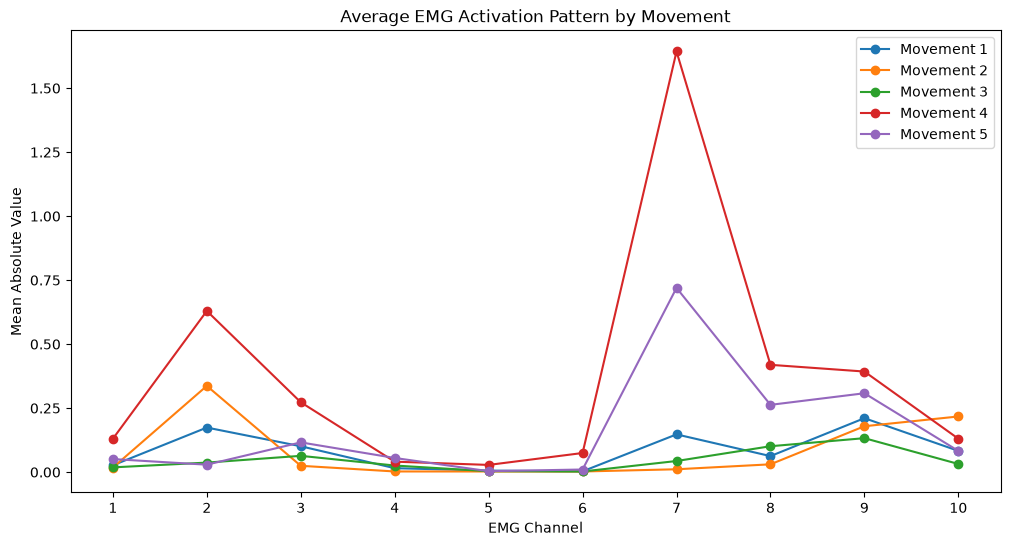

In [34]:
plt.figure(figsize=(12, 6))

for i, movement in enumerate(movements):
    plt.plot(
        range(1, 11),
        movement_means[i],
        marker="o",
        label=f"Movement {movement}"
    )

plt.xlabel("EMG Channel")
plt.ylabel("Mean Absolute Value")
plt.title("Average EMG Activation Pattern by Movement")
plt.xticks(range(1, 11))
plt.legend()

plt.show()

In [35]:
train_mask = rep_ids <= 8
test_mask = rep_ids >= 9

X_train = X_mav[train_mask]
X_test = X_mav[test_mask]

y_train = y[train_mask]
y_test = y[test_mask]

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)

Training data: (1350, 10)
Testing data: (329, 10)
Training labels: (1350,)
Testing labels: (329,)


In [41]:
#import classifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [42]:
#create model
model = make_pipeline(
    StandardScaler(),
    LinearDiscriminantAnalysis()
)

In [44]:
#train model
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('lineardiscriminantanalysis', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](5,)","[1,2,3,4,5]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [45]:
#predictions
y_pred = model.predict(X_test)

In [46]:
print("Actual:   ", y_test[:20])
print("Predicted:", y_pred[:20])

Actual:    [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Predicted: [3 3 3 3 3 3 3 3 3 3 2 2 2 1 1 1 1 1 1 1]


In [47]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 0.7689969604863222
Accuracy: 76.90%


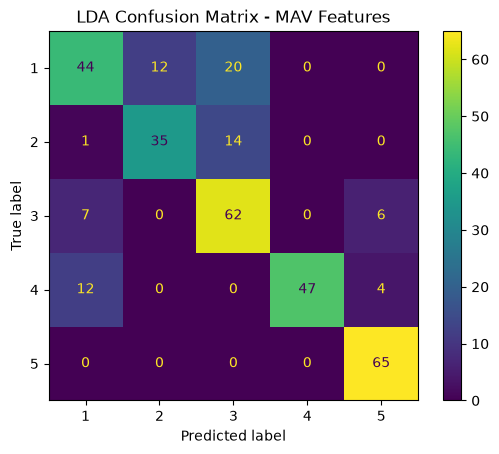

In [49]:
#confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=movements
)

plt.title("LDA Confusion Matrix - MAV Features")
plt.show()

In [50]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.69      0.58      0.63        76
           2       0.74      0.70      0.72        50
           3       0.65      0.83      0.73        75
           4       1.00      0.75      0.85        63
           5       0.87      1.00      0.93        65

    accuracy                           0.77       329
   macro avg       0.79      0.77      0.77       329
weighted avg       0.78      0.77      0.77       329



In [61]:
#add root mean square to features (mean absolute value already there)

In [51]:
X_rms = np.sqrt(np.mean(X ** 2, axis=1))

print("RMS shape:", X_rms.shape)

RMS shape: (1679, 10)


In [52]:
print("MAV:", X_mav[0])
print("RMS:", X_rms[0])

MAV: [0.03272  0.026115 0.002525 0.0024   0.002525 0.0024   0.08861  0.05859
 0.00277  0.010855]
RMS: [0.03550841 0.03634486 0.00258312 0.0024     0.00258312 0.0024
 0.09140404 0.06099066 0.00320531 0.01231075]


In [54]:
X_features = np.concatenate(
    [X_mav, X_rms],
    axis=1
)

print(X_features.shape)

(1679, 20)


In [57]:
#train model again

In [58]:
X_train = X_features[rep_ids <= 8]
X_test = X_features[rep_ids >= 9]

y_train = y[rep_ids <= 8]
y_test = y[rep_ids >= 9]

In [59]:
model = make_pipeline(
    StandardScaler(),
    LinearDiscriminantAnalysis()
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [60]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 80.55%


In [63]:
#add waveform length to features

In [62]:
X_wl = np.sum(
    np.abs(np.diff(X, axis=1)),
    axis=1
)

print("Waveform length shape:", X_wl.shape)

Waveform length shape: (1679, 10)


In [64]:
X_features = np.concatenate(
    [X_mav, X_rms, X_wl],
    axis=1
)

print(X_features.shape)

(1679, 30)


In [67]:
#retrain
X_train = X_features[rep_ids <= 8]
X_test = X_features[rep_ids >= 9]

y_train = y[rep_ids <= 8]
y_test = y[rep_ids >= 9]

model = make_pipeline(
    StandardScaler(),
    LinearDiscriminantAnalysis()
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 86.02%


In [68]:
results = {
    "MAV": 76.90,
    "MAV + RMS": 80.55,
    "MAV + RMS + WL": 86.02
}

results

{'MAV': 76.9, 'MAV + RMS': 80.55, 'MAV + RMS + WL': 86.02}

In [69]:
#add zero-crossing to features

In [70]:
X_zc = np.sum(
    X[:, 1:, :] * X[:, :-1, :] < 0,
    axis=1
)

print("Zero crossing shape:", X_zc.shape)

Zero crossing shape: (1679, 10)


In [71]:
X_features = np.concatenate(
    [X_mav, X_rms, X_wl, X_zc],
    axis=1
)

print(X_features.shape)

(1679, 40)


In [73]:
#retrain
X_train = X_features[rep_ids <= 8]
X_test = X_features[rep_ids >= 9]

y_train = y[rep_ids <= 8]
y_test = y[rep_ids >= 9]

model = make_pipeline(
    StandardScaler(),
    LinearDiscriminantAnalysis()
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 86.02%


In [75]:
# accuracy stayed the same - zero crossing is not useful in this form
results = {
    "MAV": 76.90,
    "MAV + RMS": 80.55,
    "MAV + RMS + WL": 86.02,
    "MAV + RMS + WL + ZC": 86.02
}

results

{'MAV': 76.9,
 'MAV + RMS': 80.55,
 'MAV + RMS + WL': 86.02,
 'MAV + RMS + WL + ZC': 86.02}

In [77]:
#drop ZC
X_features = np.concatenate(
    [X_mav, X_rms, X_wl],
    axis=1
)

In [78]:
X_train = X_features[rep_ids <= 8]
X_test = X_features[rep_ids >= 9]

y_train = y[rep_ids <= 8]
y_test = y[rep_ids >= 9]

In [81]:
#let's test three other models

In [80]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [82]:
models = {
    "LDA": make_pipeline(
        StandardScaler(),
        LinearDiscriminantAnalysis()
    ),

    "Logistic Regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=2000)
    ),

    "SVM": make_pipeline(
        StandardScaler(),
        SVC()
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )
}

In [83]:
model_results = {}

for name, model in models.items():
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    model_results[name] = accuracy

    print(f"{name}: {accuracy * 100:.2f}%")

LDA: 86.02%
Logistic Regression: 88.75%
SVM: 82.37%
Random Forest: 90.88%


In [84]:
from sklearn.model_selection import LeaveOneGroupOut

In [85]:
logo = LeaveOneGroupOut()

In [86]:
cv_results = {
    name: []
    for name in models
}

for train_idx, test_idx in logo.split(
    X_features,
    y,
    groups=rep_ids
):
    X_train = X_features[train_idx]
    X_test = X_features[test_idx]

    y_train = y[train_idx]
    y_test = y[test_idx]

    for name, model in models.items():

        model.fit(X_train, y_train)

        predictions = model.predict(X_test)

        accuracy = accuracy_score(
            y_test,
            predictions
        )

        cv_results[name].append(accuracy)

In [87]:
for name, scores in cv_results.items():

    print(name)

    for rep, score in enumerate(scores, start=1):
        print(
            f"  Test repetition {rep}: "
            f"{score * 100:.2f}%"
        )

    print()

LDA
  Test repetition 1: 52.00%
  Test repetition 2: 81.22%
  Test repetition 3: 83.13%
  Test repetition 4: 86.75%
  Test repetition 5: 83.24%
  Test repetition 6: 93.64%
  Test repetition 7: 86.71%
  Test repetition 8: 87.97%
  Test repetition 9: 86.75%
  Test repetition 10: 84.05%

Logistic Regression
  Test repetition 1: 57.14%
  Test repetition 2: 83.98%
  Test repetition 3: 93.98%
  Test repetition 4: 84.94%
  Test repetition 5: 96.53%
  Test repetition 6: 98.84%
  Test repetition 7: 89.87%
  Test repetition 8: 94.94%
  Test repetition 9: 92.77%
  Test repetition 10: 91.41%

SVM
  Test repetition 1: 49.71%
  Test repetition 2: 79.01%
  Test repetition 3: 91.57%
  Test repetition 4: 88.55%
  Test repetition 5: 96.53%
  Test repetition 6: 98.27%
  Test repetition 7: 89.24%
  Test repetition 8: 93.67%
  Test repetition 9: 89.76%
  Test repetition 10: 88.96%

Random Forest
  Test repetition 1: 56.57%
  Test repetition 2: 85.64%
  Test repetition 3: 90.96%
  Test repetition 4: 82.53%


In [88]:
for name, scores in cv_results.items():

    mean_accuracy = np.mean(scores)
    std_accuracy = np.std(scores)

    print(
        f"{name}: "
        f"{mean_accuracy * 100:.2f}% "
        f"+/- {std_accuracy * 100:.2f}%"
    )

LDA: 82.55% +/- 10.69%
Logistic Regression: 88.44% +/- 11.35%
SVM: 86.53% +/- 13.24%
Random Forest: 88.05% +/- 11.74%


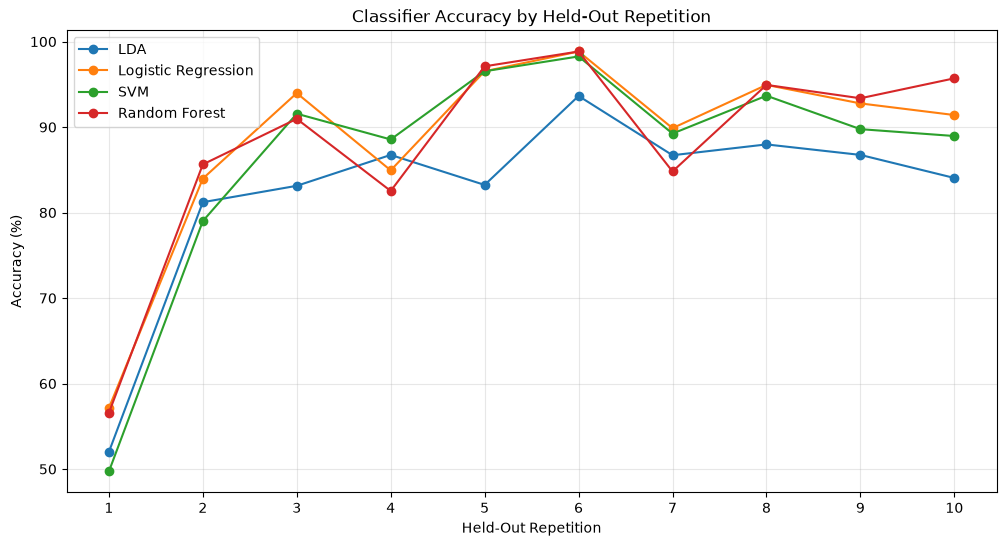

In [89]:
plt.figure(figsize=(12, 6))

for name, scores in cv_results.items():
    plt.plot(
        range(1, 11),
        np.array(scores) * 100,
        marker="o",
        label=name
    )

plt.xlabel("Held-Out Repetition")
plt.ylabel("Accuracy (%)")
plt.title("Classifier Accuracy by Held-Out Repetition")

plt.xticks(range(1, 11))
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [90]:
for name, scores in cv_results.items():
    hardest_rep = np.argmin(scores) + 1
    hardest_score = np.min(scores)

    print(
        f"{name}: hardest repetition = {hardest_rep}, "
        f"accuracy = {hardest_score * 100:.2f}%"
    )

LDA: hardest repetition = 1, accuracy = 52.00%
Logistic Regression: hardest repetition = 1, accuracy = 57.14%
SVM: hardest repetition = 1, accuracy = 49.71%
Random Forest: hardest repetition = 1, accuracy = 56.57%


In [91]:
for name, scores in cv_results.items():
    easiest_rep = np.argmax(scores) + 1
    easiest_score = np.max(scores)

    print(
        f"{name}: easiest repetition = {easiest_rep}, "
        f"accuracy = {easiest_score * 100:.2f}%"
    )

LDA: easiest repetition = 6, accuracy = 93.64%
Logistic Regression: easiest repetition = 6, accuracy = 98.84%
SVM: easiest repetition = 6, accuracy = 98.27%
Random Forest: easiest repetition = 6, accuracy = 98.84%


In [92]:
from sklearn.base import clone

best_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000)
)

cv_predictions = np.zeros_like(y)

logo = LeaveOneGroupOut()

for train_idx, test_idx in logo.split(
    X_features,
    y,
    groups=rep_ids
):
    model = clone(best_model)

    model.fit(
        X_features[train_idx],
        y[train_idx]
    )

    cv_predictions[test_idx] = model.predict(
        X_features[test_idx]
    )

In [93]:
cv_accuracy = accuracy_score(
    y,
    cv_predictions
)

print(f"Overall CV accuracy: {cv_accuracy * 100:.2f}%")

Overall CV accuracy: 88.27%


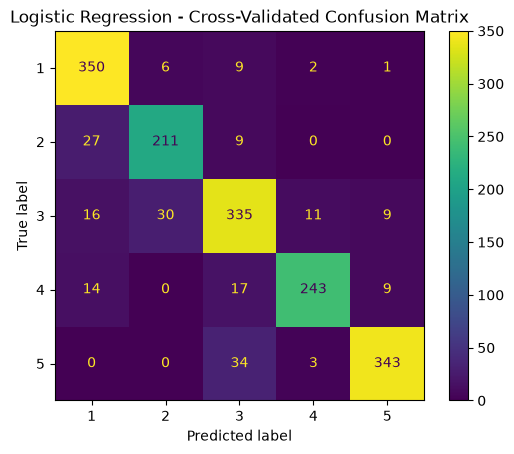

In [94]:
ConfusionMatrixDisplay.from_predictions(
    y,
    cv_predictions,
    labels=movements
)

plt.title(
    "Logistic Regression - Cross-Validated Confusion Matrix"
)

plt.show()

In [95]:
print(
    classification_report(
        y,
        cv_predictions,
        labels=movements
    )
)

              precision    recall  f1-score   support

           1       0.86      0.95      0.90       368
           2       0.85      0.85      0.85       247
           3       0.83      0.84      0.83       401
           4       0.94      0.86      0.90       283
           5       0.95      0.90      0.92       380

    accuracy                           0.88      1679
   macro avg       0.89      0.88      0.88      1679
weighted avg       0.88      0.88      0.88      1679



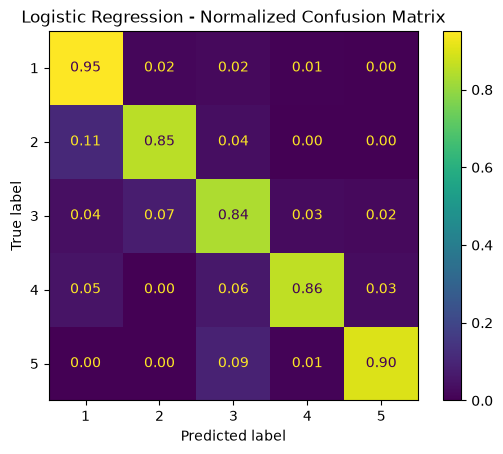

In [96]:
ConfusionMatrixDisplay.from_predictions(
    y,
    cv_predictions,
    labels=movements,
    normalize="true",
    values_format=".2f"
)

plt.title(
    "Logistic Regression - Normalized Confusion Matrix"
)

plt.show()

In [97]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y,
    cv_predictions,
    labels=movements
)

for i, actual in enumerate(movements):
    for j, predicted in enumerate(movements):

        if actual != predicted and cm[i, j] > 0:

            print(
                f"Movement {actual} → Movement {predicted}: "
                f"{cm[i, j]} windows"
            )

Movement 1 → Movement 2: 6 windows
Movement 1 → Movement 3: 9 windows
Movement 1 → Movement 4: 2 windows
Movement 1 → Movement 5: 1 windows
Movement 2 → Movement 1: 27 windows
Movement 2 → Movement 3: 9 windows
Movement 3 → Movement 1: 16 windows
Movement 3 → Movement 2: 30 windows
Movement 3 → Movement 4: 11 windows
Movement 3 → Movement 5: 9 windows
Movement 4 → Movement 1: 14 windows
Movement 4 → Movement 3: 17 windows
Movement 4 → Movement 5: 9 windows
Movement 5 → Movement 3: 34 windows
Movement 5 → Movement 4: 3 windows


In [98]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y,
    cv_predictions,
    labels=movements
)

confusions = []

for i, actual in enumerate(movements):
    for j, predicted in enumerate(movements):
        if actual != predicted:
            confusions.append(
                (cm[i, j], actual, predicted)
            )

confusions.sort(reverse=True)

for count, actual, predicted in confusions[:5]:
    print(
        f"Movement {actual} → Movement {predicted}: "
        f"{count} windows"
    )

Movement 5 → Movement 3: 34 windows
Movement 3 → Movement 2: 30 windows
Movement 2 → Movement 1: 27 windows
Movement 4 → Movement 3: 17 windows
Movement 3 → Movement 1: 16 windows


In [101]:
#helper to build dataset
def build_dataset(emg, labels, repetitions, movements, window_size):
    X = []
    y = []
    rep_ids = []

    step_size = window_size // 2  # 50% overlap

    for movement in movements:
        for rep in range(1, 11):

            mask = (
                (labels == movement) &
                (repetitions == rep)
            )

            signal = emg[mask]

            windows = create_windows(
                signal,
                window_size=window_size,
                step_size=step_size
            )

            for window in windows:
                X.append(window)
                y.append(movement)
                rep_ids.append(rep)

    return (
        np.array(X),
        np.array(y),
        np.array(rep_ids)
    )

In [104]:
#feature extraction function
def extract_features(X):
    mav = np.mean(np.abs(X), axis=1)

    rms = np.sqrt(
        np.mean(X ** 2, axis=1)
    )

    wl = np.sum(
        np.abs(np.diff(X, axis=1)),
        axis=1
    )

    features = np.concatenate(
        [mav, rms, wl],
        axis=1
    )

    return features

In [105]:
window_sizes = [10, 15, 20, 25, 30]

window_results = {}

In [106]:
for window_size in window_sizes:

    # Build dataset
    X_temp, y_temp, reps_temp = build_dataset(
        emg,
        labels,
        repetitions,
        movements,
        window_size
    )

    # Extract features
    X_temp_features = extract_features(X_temp)

    # Model
    model = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=2000)
    )

    # Cross-validation
    logo = LeaveOneGroupOut()

    scores = []

    for train_idx, test_idx in logo.split(
        X_temp_features,
        y_temp,
        groups=reps_temp
    ):

        model.fit(
            X_temp_features[train_idx],
            y_temp[train_idx]
        )

        predictions = model.predict(
            X_temp_features[test_idx]
        )

        score = accuracy_score(
            y_temp[test_idx],
            predictions
        )

        scores.append(score)

    window_results[window_size] = scores

    print(
        f"{window_size} samples: "
        f"{np.mean(scores) * 100:.2f}% "
        f"+/- {np.std(scores) * 100:.2f}%"
    )

10 samples: 86.78% +/- 11.68%
15 samples: 87.25% +/- 12.17%
20 samples: 88.44% +/- 11.35%
25 samples: 88.43% +/- 11.16%
30 samples: 88.98% +/- 10.90%


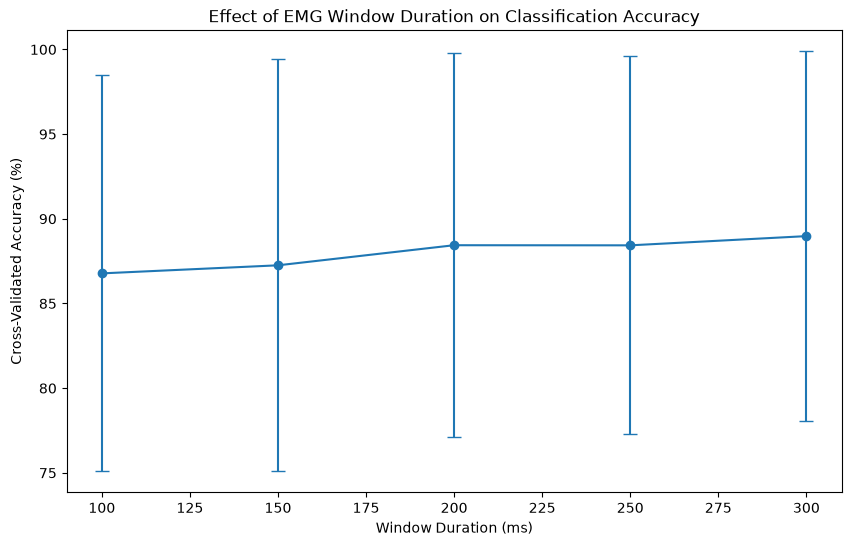

In [107]:
mean_scores = [
    np.mean(window_results[w]) * 100
    for w in window_sizes
]

std_scores = [
    np.std(window_results[w]) * 100
    for w in window_sizes
]

durations_ms = [
    w / 100 * 1000
    for w in window_sizes
]

plt.figure(figsize=(10, 6))

plt.errorbar(
    durations_ms,
    mean_scores,
    yerr=std_scores,
    marker="o",
    capsize=5
)

plt.xlabel("Window Duration (ms)")
plt.ylabel("Cross-Validated Accuracy (%)")
plt.title("Effect of EMG Window Duration on Classification Accuracy")

plt.show()

In [109]:
import pandas as pd

In [110]:
window_summary = []

for window_size in window_sizes:
    scores = window_results[window_size]

    window_summary.append({
        "window_samples": window_size,
        "window_ms": window_size / 100 * 1000,
        "mean_accuracy": np.mean(scores),
        "std_accuracy": np.std(scores)
    })

window_df = pd.DataFrame(window_summary)

window_df

,window_samples,window_ms,mean_accuracy,std_accuracy
0,10,100.0,0.867780,0.116850
1,15,150.0,0.872542,0.121740
2,20,200.0,0.884404,0.113485
3,25,250.0,0.884338,0.111556
4,30,300.0,0.889777,0.109012


In [111]:
window_df.to_csv(
    "../results/window_size_experiment.csv",
    index=False
)

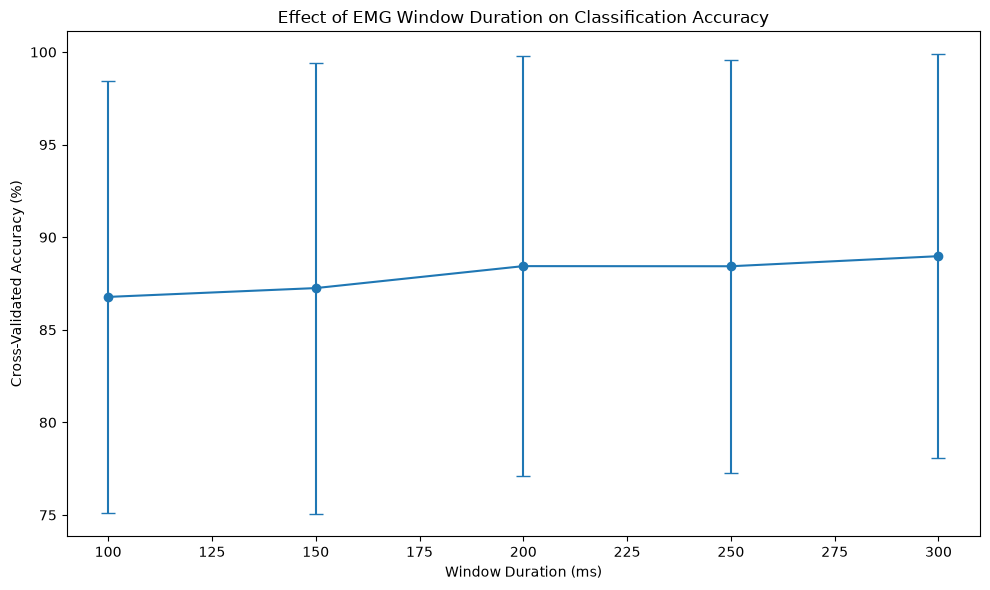

In [112]:
plt.figure(figsize=(10, 6))

plt.errorbar(
    durations_ms,
    mean_scores,
    yerr=std_scores,
    marker="o",
    capsize=5
)

plt.xlabel("Window Duration (ms)")
plt.ylabel("Cross-Validated Accuracy (%)")
plt.title("Effect of EMG Window Duration on Classification Accuracy")

plt.tight_layout()

plt.savefig(
    "../results/window_size_experiment.png",
    dpi=300
)

plt.show()

In [113]:
WINDOW_SIZE = 20      # 200 ms at 100 Hz
STEP_SIZE = 10        # 100 ms, 50% overlap

FEATURES = [
    "MAV",
    "RMS",
    "Waveform Length"
]

CURRENT_MODEL = "Logistic Regression"